In [ ]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [ ]:
%%capture
!pip install lightning torchinfo

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.accelerators import accelerator
from torchmetrics import functional as FM
from torchinfo import summary

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import torch.utils as utils
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

torch.__version__,pl.__version__
device = "cuda"

# Optimization(2)

# Weighted Cross-Entorpy Loss

```python
nSamples = [887, 6130, 480, 317, 972, 101, 128]
normedWeights = [1 - (x / sum(nSamples)) for x in nSamples]
normedWeights = torch.FloatTensor(normedWeights)

loss = nn.CrossEntropyLoss(normedWeights)
```

In [ ]:
116 * 114 + 178 * 157

41170

## Imbalanced Dataset 준비

In [ ]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import torch.utils as utils
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [ ]:
transform=transforms.Compose([transforms.ToTensor()])
mnist_test = MNIST("", train=False, transform=transform, download=True)
mnist_full = MNIST("", train=True, transform=transform, download=True)

batch_size=64
test_loader = DataLoader(mnist_test,batch_size=batch_size)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]


Extracting MNIST/raw/train-images-idx3-ubyte.gz to MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]


Extracting MNIST/raw/train-labels-idx1-ubyte.gz to MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]


Extracting MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.45MB/s]

Extracting MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST/raw



In [ ]:
mnist_x = np.array([np.array(x[0]) for x in mnist_full])
mnist_y = np.array([np.array(x[1]) for x in mnist_full])

In [ ]:
ps(mnist_x)
ps(mnist_y)

[] Shape(60000, 1, 28, 28)
[] Shape(60000,)


In [ ]:
## 숫자별로 재배치
mnist_sub = [[],[],[],[],[],[],[],[],[],[]]
for x,y in zip(mnist_x,mnist_y):
  prob = np.random.random(1)
  if (y < 5 and prob >= 0.5) or (y >= 5 and prob >= 0.10):
    pass
  else :
    mnist_sub[y].append(x)

In [ ]:
cnt = 0
for i in mnist_sub:
  print(len(i))
  cnt += len(i)
print("total:",cnt)

3001
3355
3029
3076
2922
543
599
667
568
581
total: 18341


In [ ]:
mnist2 = []
for i,imgs in enumerate(mnist_sub):
  for j in range(len(imgs)):
    mnist2.append((mnist_sub[i][j], np.array(i)))#.reshape(-1,)))

In [ ]:
print(len(mnist2))
ps(mnist2[0][0],'image')
ps(mnist2[0][1],'label')

18341
[image] Shape(1, 28, 28)
[label] Shape()


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, x):
        self.x = x
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index: int):
        img,label = self.x[index]
        img = img.reshape(1,28,28)
        return img,label

In [ ]:
mnist2_dataset = CustomDataset(mnist2)

In [ ]:
train_n = len(mnist2_dataset)
print(train_n)
split_n = int(0.3*train_n)

mnist_train, mnist_val = utils.data.random_split(mnist2_dataset, [train_n-split_n, split_n])
print(len(mnist_train),len(mnist_val))

18341
12839 5502


In [ ]:
train_loader = DataLoader(mnist_train, batch_size=64)
val_loader = DataLoader(mnist_val, batch_size=64)
print(len(train_loader),len(val_loader))

201 86


In [ ]:
batch = next(iter(train_loader))
ps(batch[0], 'img')
ps(batch[1], 'idx')

[img] Shapetorch.Size([64, 1, 28, 28])
[idx] Shapetorch.Size([64])


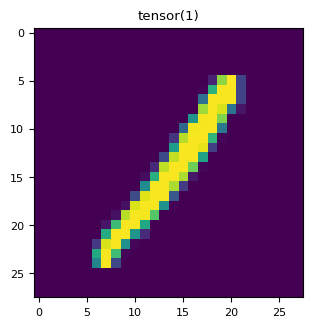

In [ ]:
plt.title(str(batch[1][0]))
plt.imshow(batch[0][0][0])
plt.show()

## Base Model : Normal CE loss

In [ ]:
class Model(pl.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10))

    def forward(self, x):
        x = self.layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = Model()
summary(model, input_size=(8, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 784]                  --
│    └─Linear: 2-2                       [8, 128]                  100,480
│    └─ReLU: 2-3                         [8, 128]                  --
│    └─Linear: 2-4                       [8, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (M): 0.81
Input size (MB): 0.03
Forward/backward pass size (MB): 0.01
Params size (MB): 0.41
Estimated Total Size (MB): 0.44

In [ ]:
%%time
model = Model()

name="normal_CE"
logger = pl.loggers.CSVLogger("logs", name=name)
trainer = pl.Trainer(max_epochs=50, logger=logger,limit_train_batches=0.3,limit_val_batches=0.3)
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name   | Type       | Params | Mode 
----------------------------------------------
0 | layers | Sequential | 101 K  | train
----------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.407     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


CPU times: user 21.5 s, sys: 565 ms, total: 22.1 s
Wall time: 21.9 s


In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

**Test Data로 숫자별 accuracy 확인**

In [ ]:
trainer.validate(model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8766622543334961     │
│         val_loss          │    0.5854859948158264     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.5854859948158264, 'val_acc': 0.8766622543334961}]

In [ ]:
acc_num = [[],[],[],[],[],[],[],[],[],[]]
for x,y in test_loader:
  pred = model(x)
  pred_y = torch.argmax(pred,axis=1)
  for i, y1 in enumerate(y):
    acc_num[y1].append((pred_y[i]==y1))

acc_mean = 0
acc = []
for i,l in enumerate(acc_num):
  acc.append(sum(l)/len(l))
  print(f"{i}: acc({acc[-1]:.4f})")
  acc_mean += acc[-1]*(len(l)/len(mnist_test))
print("acc_mean:",acc_mean)

print(np.mean(acc),np.std(acc))

0: acc(0.9837)
1: acc(0.9885)
2: acc(0.9419)
3: acc(0.9485)
4: acc(0.9705)
5: acc(0.7971)
6: acc(0.8633)
7: acc(0.8813)
8: acc(0.8357)
9: acc(0.7810)
acc_mean: tensor(0.9015)
0.8991429 0.07382079


## F1 score Loss  

In [ ]:
from torchmetrics import AveragePrecision
from torchmetrics.classification import MulticlassF1Score
from torchmetrics.classification import MulticlassAUROC

https://www.evidentlyai.com/classification-metrics/multi-class-metrics

In [ ]:
class F1Loss(nn.Module):
    def __init__(self, epsilon=1e-7):
        super(F1Loss, self).__init__()
        self.epsilon = epsilon

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=probs.size(1)).float()
        true_positives = torch.sum(probs * targets_one_hot, dim=0)
        predicted_positives = torch.sum(probs, dim=0)
        actual_positives = torch.sum(targets_one_hot, dim=0)
        # Calculate precision and recall
        precision = true_positives / (predicted_positives + self.epsilon)
        recall = true_positives / (actual_positives + self.epsilon)
        # Compute F1 Score
        f1 = 2 * (precision * recall) / (precision + recall + self.epsilon)
        f1 = f1.clamp(min=self.epsilon)  # Avoid NaNs
        # F1 Loss (maximize F1 -> minimize 1 - F1)
        return 1 - f1.mean()

In [ ]:
#loss_func = nn.CrossEntropyLoss().to(device)
loss_func = F1Loss().to(device)

class Model5(pl.LightningModule):
    def __init__(self):
        super(Model5, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10))

    def forward(self, x):
        x = self.layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        y_pred_idx = torch.argmax(y_pred,dim=1).type(dtype=torch.float)
        loss = loss_func(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc,
                 }
        self.log_dict(metrics, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        y_pred_idx = torch.argmax(y_pred,dim=1).type(dtype=torch.float)
        loss = loss_func(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc,
                 }
        self.log_dict(metrics, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = Model5()
summary(model, input_size=(8, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model5                                   [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 784]                  --
│    └─Linear: 2-2                       [8, 128]                  100,480
│    └─ReLU: 2-3                         [8, 128]                  --
│    └─Linear: 2-4                       [8, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (M): 0.81
Input size (MB): 0.03
Forward/backward pass size (MB): 0.01
Params size (MB): 0.41
Estimated Total Size (MB): 0.44

In [ ]:
%%time
model = Model5()

name = 'F1'
logger = pl.loggers.CSVLogger("logs", name=name)
trainer = pl.Trainer(max_epochs=50, logger=logger,limit_train_batches=0.3,limit_val_batches=0.3)
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name   | Type       | Params | Mode 
----------------------------------------------
0 | layers | Sequential | 101 K  | train
----------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.407     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


CPU times: user 24.9 s, sys: 586 ms, total: 25.5 s
Wall time: 25.3 s


In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df2 = history.groupby('epoch').last().drop('step', axis=1)

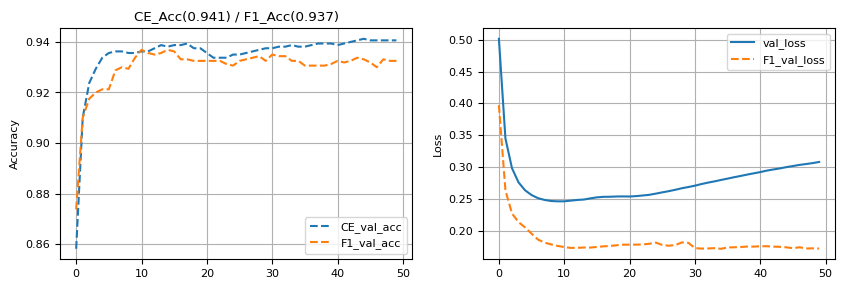

In [ ]:
plt.figure(figsize=(10, 3.))
plt.subplot(1, 2, 1)
plt.title(f"CE_Acc({df['val_acc'].max():.3f}) / F1_Acc({df2['val_acc'].max():.3f})")
plt.plot(df['val_acc'], linestyle='--', label="CE_val_acc")
plt.plot(df2['val_acc'], linestyle='--', label="F1_val_acc")
#plt.ylim(0.,1.1)
plt.grid()
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df['val_loss'], linestyle='-', label="val_loss")
plt.plot(df2['val_loss'], linestyle='--', label="F1_val_loss")
plt.grid()
plt.ylabel('Loss')
plt.legend()
plt.show()

**Test Data로 숫자별 accuracy 확인**

In [ ]:
trainer.validate(model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8560505509376526     │
│         val_loss          │    0.16609977185726166    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.16609977185726166, 'val_acc': 0.8560505509376526}]

In [ ]:
acc_num = [[],[],[],[],[],[],[],[],[],[]]
for x,y in test_loader:
  pred = model(x)
  pred_y = torch.argmax(pred,axis=1)
  for i, y1 in enumerate(y):
    acc_num[y1].append((pred_y[i]==y1))

acc_mean = 0
acc = []
for i,l in enumerate(acc_num):
  acc.append(sum(l)/len(l))
  print(f"{i}: acc({acc[-1]:.4f})")
  acc_mean += acc[-1]*(len(l)/len(mnist_test))
print("acc_mean:",acc_mean)

print(np.mean(acc),np.std(acc))

0: acc(0.9837)
1: acc(0.9806)
2: acc(0.9205)
3: acc(0.9436)
4: acc(0.9654)
5: acc(0.7466)
6: acc(0.8215)
7: acc(0.8667)
8: acc(0.8101)
9: acc(0.7988)
acc_mean: tensor(0.8867)
0.88375175 0.08159121


## Weighted CE loss 적용

In [ ]:
cnt = 0
tot_num_l = []
for i in mnist_sub:
  tot_num_l.append(len(i))
tot_num = sum(tot_num_l)
print("total:",tot_num)
print(tot_num_l)

total: 18341
[3001, 3355, 3029, 3076, 2922, 543, 599, 667, 568, 581]


In [ ]:
class_weights = [(tot_num / count) for count in tot_num_l]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
for i in class_weights_tensor: print(f"{i:.3f}, ",end="")

6.112, 5.467, 6.055, 5.963, 6.277, 33.777, 30.619, 27.498, 32.290, 31.568, 

In [ ]:
loss_func = nn.CrossEntropyLoss(class_weights_tensor).to(device)
class Model6(pl.LightningModule):
    def __init__(self):
        super(Model6, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10))

    def forward(self, x):
        x = self.layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = loss_func(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = loss_func(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = Model6()
summary(model, input_size=(8, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model6                                   [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 784]                  --
│    └─Linear: 2-2                       [8, 128]                  100,480
│    └─ReLU: 2-3                         [8, 128]                  --
│    └─Linear: 2-4                       [8, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (M): 0.81
Input size (MB): 0.03
Forward/backward pass size (MB): 0.01
Params size (MB): 0.41
Estimated Total Size (MB): 0.44

In [ ]:
%%time
model = Model6()

name = 'Weighted CE'
logger = pl.loggers.CSVLogger("logs", name=name)
trainer = pl.Trainer(max_epochs=50, logger=logger,limit_train_batches=0.3,limit_val_batches=0.3)
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name   | Type       | Params | Mode 
----------------------------------------------
0 | layers | Sequential | 101 K  | train
----------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.407     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


CPU times: user 22.1 s, sys: 657 ms, total: 22.7 s
Wall time: 22.5 s


In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df3 = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
plt.figure(figsize=(10, 3.))
plt.subplot(1, 2, 1)
plt.title(f"CE({df['val_acc'].max():.3f}),F1({df2['val_acc'].max():.3f}), WCE({df3['val_acc'].max():.3f})")
plt.plot(df['val_acc'], linestyle='--', label="CE_val_acc")
plt.plot(df2['val_acc'], linestyle='--', label="F1_val_acc")
plt.plot(df3['val_acc'], linestyle='--', label="WCE_val_acc")
#plt.ylim(0.,1.1)
plt.grid()
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df['val_loss'], linestyle='--', label="CE_val_loss")
plt.plot(df2['val_loss'], linestyle='--', label="F1_val_loss")
plt.plot(df3['val_loss'], linestyle='--', label="WCE_val_loss")
plt.grid()
plt.ylabel('Loss')
plt.legend()
plt.show()

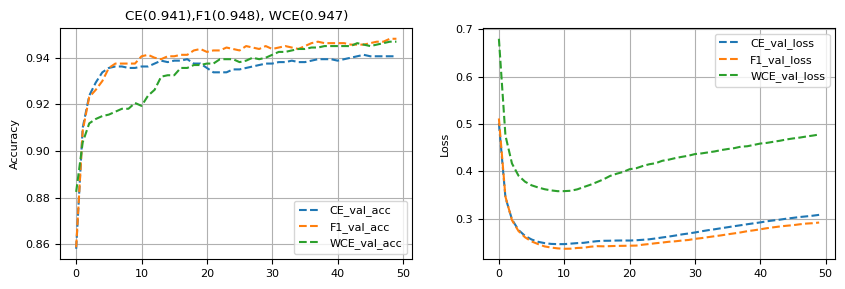

In [ ]:
trainer.validate(model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │     0.883643627166748     │
│         val_loss          │    0.8141486048698425     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.8141486048698425, 'val_acc': 0.883643627166748}]

In [ ]:
acc_num = [[],[],[],[],[],[],[],[],[],[]]
for x,y in test_loader:
  pred = model(x)
  pred_y = torch.argmax(pred,axis=1)
  for i, y1 in enumerate(y):
    acc_num[y1].append((pred_y[i]==y1))

acc_mean = 0
acc = []
for i,l in enumerate(acc_num):
  acc.append(sum(l)/len(l))
  print(f"{i}: acc({acc[-1]:.4f})")
  acc_mean += acc[-1]*(len(l)/len(mnist_test))
print("acc_mean:",acc_mean)

print(np.mean(acc),np.std(acc))

0: acc(0.9816)
1: acc(0.9859)
2: acc(0.9283)
3: acc(0.9317)
4: acc(0.9613)
5: acc(0.8161)
6: acc(0.8789)
7: acc(0.8872)
8: acc(0.8593)
9: acc(0.8196)
acc_mean: tensor(0.9070)
0.90500003 0.059254136


## Focal Loss

In [ ]:
# 클래스별 반비례 weight 계산
alphaWeights = [(tot_num / count) for count in tot_num_l]

# 정규화: 총합이 1이 되도록
alphaWeights = [alpha / sum(alphaWeights) for alpha in alphaWeights]

# Tensor로 변환
alphaWeights_tensor = torch.FloatTensor(alphaWeights)
print("Alpha Weights:", alphaWeights_tensor)

Alpha Weights: tensor([0.0329, 0.0295, 0.0326, 0.0321, 0.0338, 0.1820, 0.1650, 0.1481, 0.1740,
        0.1701])


In [ ]:
# Focal Loss 클래스에 적용
class FocalLoss(nn.modules.loss._WeightedLoss):
    def __init__(self, weight=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__(weight, reduction=reduction)
        self.gamma = gamma
        self.weight = weight  # alpha weights for class imbalance

    def forward(self, input, target):
        # Cross-entropy loss with weights
        ce_loss = F.cross_entropy(input, target, reduction=self.reduction, weight=self.weight)
        pt = torch.exp(-ce_loss)  # Probabilities for true classes
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

In [ ]:
loss_func = FocalLoss(weight=alphaWeights_tensor, gamma=0.7).to(device)

class Model7(pl.LightningModule):
    def __init__(self):
        super(Model7, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10))

    def forward(self, x):
        x = self.layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = loss_func(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = loss_func(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = Model7()
summary(model, input_size=(8, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model7                                   [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 784]                  --
│    └─Linear: 2-2                       [8, 128]                  100,480
│    └─ReLU: 2-3                         [8, 128]                  --
│    └─Linear: 2-4                       [8, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (M): 0.81
Input size (MB): 0.03
Forward/backward pass size (MB): 0.01
Params size (MB): 0.41
Estimated Total Size (MB): 0.44

In [ ]:
%%time
model = Model7()

name = 'Focal_Loss'
logger = pl.loggers.CSVLogger("logs", name=name)
trainer = pl.Trainer(max_epochs=50, logger=logger,limit_train_batches=0.3,limit_val_batches=0.3)
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name   | Type       | Params | Mode 
----------------------------------------------
0 | layers | Sequential | 101 K  | train
----------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.407     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


CPU times: user 22.9 s, sys: 654 ms, total: 23.5 s
Wall time: 23.5 s


In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df4 = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
plt.figure(figsize=(10, 3.))
plt.subplot(1, 2, 1)
plt.title(f"CE({df['val_acc'].max():.3f}),F1({df2['val_acc'].max():.3f}), \
WCE({df3['val_acc'].max():.3f}, Focal_Loss({df4['val_acc'].max():.3f}))")

plt.plot(df['val_acc'], linestyle='--', label="CE_val_acc")
plt.plot(df2['val_acc'], linestyle='--', label="F1_val_acc")
plt.plot(df3['val_acc'], linestyle='--', label="WCE_val_acc")
plt.plot(df4['val_acc'], linestyle='--', label="FL_val_acc")
#plt.ylim(0.,1.1)
plt.grid()
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df['val_loss'], linestyle='--', label="CE_val_loss")
plt.plot(df2['val_loss'], linestyle='--', label="F1_val_loss")
plt.plot(df3['val_loss'], linestyle='--', label="WCE_val_loss")
plt.plot(df4['val_loss'], linestyle='--', label="FL_val_loss")
plt.grid()
plt.ylabel('Loss')
plt.legend()
plt.show()

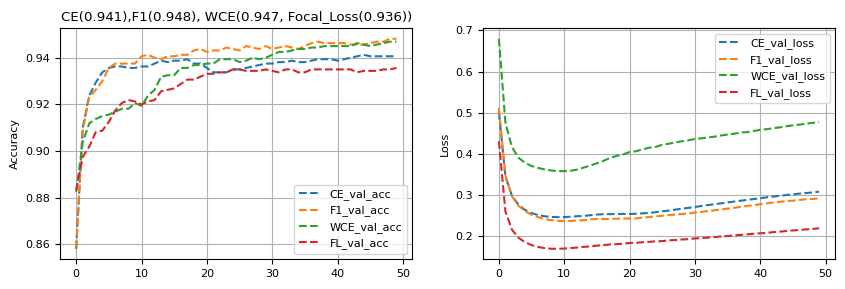

In [ ]:
trainer.validate(model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8809840679168701     │
│         val_loss          │     0.424615740776062     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.424615740776062, 'val_acc': 0.8809840679168701}]

In [ ]:
acc_num = [[],[],[],[],[],[],[],[],[],[]]
for x,y in test_loader:
  pred = model(x)
  pred_y = torch.argmax(pred,axis=1)
  for i, y1 in enumerate(y):
    acc_num[y1].append((pred_y[i]==y1))

acc_mean = 0
acc = []
for i,l in enumerate(acc_num):
  acc.append(sum(l)/len(l))
  print(f"{i}: acc({acc[-1]:.4f})")
  acc_mean += acc[-1]*(len(l)/len(mnist_test))
print("acc_mean:",acc_mean)

print(np.mean(acc),np.std(acc))

0: acc(0.9816)
1: acc(0.9841)
2: acc(0.9244)
3: acc(0.9267)
4: acc(0.9521)
5: acc(0.8419)
6: acc(0.8747)
7: acc(0.8823)
8: acc(0.8511)
9: acc(0.7948)
acc_mean: tensor(0.9031)
0.9014002 0.059601035


CE : 0.8991429 0.07382079  
F1 : 0.88375175 0.08159121  
WCE: 0.90500003 0.059254136  
FL : 0.9014002 0.059601035

